# day 30 prep

first, should i get them to use bashrc to update their PYTHONPATH and then edit `.jupyter/jupyter_server_config.py` to auto import some libraries? also how do you reset a library once you have messed with it?

| operating system --> | linux | mac | windows |
|---|---|---|---|
|1. | gnome_text_editor ./bash_rc | echo $SHELL |  |


I also need to cook up some new extensions... primarily two or three dimensional motion, each with second order equations. 

Also we need to work more on the shooting method....

In [4]:
import sys

In [5]:
sys.path

['/home/ehreming/anaconda3/lib/python312.zip',
 '/home/ehreming/anaconda3/lib/python3.12',
 '/home/ehreming/anaconda3/lib/python3.12/lib-dynload',
 '',
 '/home/ehreming/anaconda3/lib/python3.12/site-packages']

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
g = 9.81

target = 1e-10

def f(r_, t_):
    x, y, z, vx, vy, vz = r_
    fx = vx
    fy = vy
    fz = vz
    fvx = 0
    fvy = -g
    fvz = 0
    return(np.array([fx, fy, fz, fvx, fvy, fvz]))

# def crk4(f, r_i, t)
# r = np.array([x_i, y_i, z_i, vx_i, vy_i, vz_i]) # initial conditions
r = np.array([0, 100, 0, 100, 0, 0]) # initial conditions

a = 0
b = 10
N = 1000
dt = (b-a)/N

tpoints = np.arange(a, b, dt)

xpoints = []
ypoints = []
zpoints = []
vxpoints = []
vypoints = []
vzpoints = []

rpoints = []

for i in tpoints:
    rpoints.append(r)
    xpoints.append(r[0])
    ypoints.append(r[1])
    zpoints.append(r[2])
    vxpoints.append(r[3])
    vypoints.append(r[4])
    vzpoints.append(r[5])
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6



def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    n = 0
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
        n = n+1
    return(midpoint, n)

def secant(f, guess, delta=1, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x2 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        x0 = x1
        x1 = x2
        n += 1
    return(x1, n)

rpoints = np.asarray(rpoints)
rpoints = rpoints.T

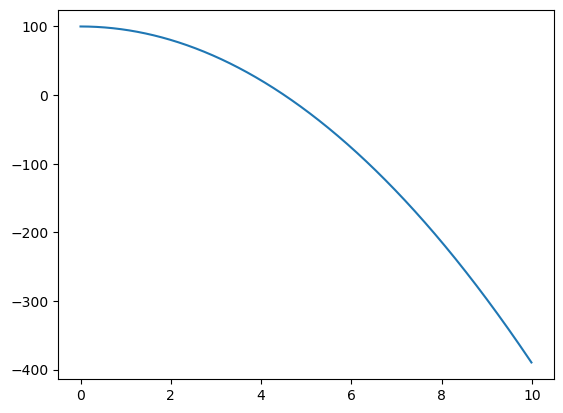

In [37]:
f0, a0 = plt.subplots()
a0.plot(tpoints, ypoints)

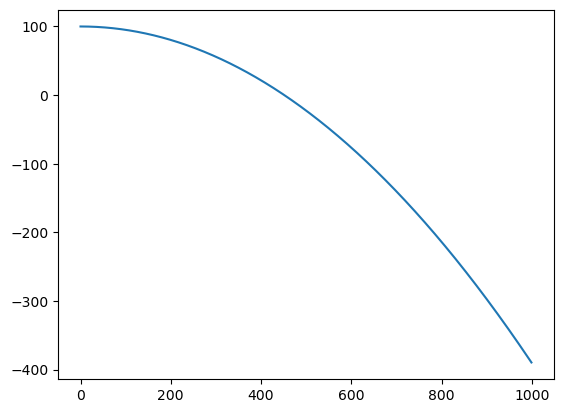

In [38]:
f1, a1 = plt.subplots()
a1.plot(rpoints[0], rpoints[1])

In [40]:
g = 9.81
m = 1
c = 1

target = 1e-10

def f(r_, t_):
    x, y, z, vx, vy, vz = r_
    fx = vx
    fy = vy
    fz = vz
    print(vx, vy, vz)
    v = np.sqrt(vx**2+vy**2+vz**2)
    fvx = -c/m*fx*v
    fvy = -g - c/m*fy*v
    fvz = 0
    return(np.array([fx, fy, fz, fvx, fvy, fvz]))

# def crk4(f, r_i, t)
# r = np.array([x_i, y_i, z_i, vx_i, vy_i, vz_i]) # initial conditions
r = np.array([0, 100, 0, 100, 0, 0]) # initial conditions

a = 0
b = 10
N = 1000
dt = (b-a)/N

tpoints = np.arange(a, b, dt)

xpoints = []
ypoints = []
zpoints = []
vxpoints = []
vypoints = []
vzpoints = []

rpoints = []

for i in tpoints:
    rpoints.append(r)
    xpoints.append(r[0])
    ypoints.append(r[1])
    zpoints.append(r[2])
    vxpoints.append(r[3])
    vypoints.append(r[4])
    vzpoints.append(r[5])
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6



def bisection(function, lower_guess, upper_guess, tolerance=2**-32):
    midpoint = (lower_guess + upper_guess)/2
    n = 0
    while upper_guess - lower_guess > tolerance:
        if function(lower_guess)*function(midpoint)<0:
            upper_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(midpoint)*function(upper_guess)<0:
            lower_guess = midpoint
            midpoint = (lower_guess + upper_guess)/2
        elif function(lower_guess)*function(midpoint)>0 and function(midpoint)*function(upper_guess)>0:
            print('no unique root in that bracket')
            break
        n = n+1
    return(midpoint, n)

def secant(f, guess, delta=1, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x2 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        x0 = x1
        x1 = x2
        n += 1
    return(x1, n)

rpoints = np.asarray(rpoints)
rpoints = rpoints.T

100 0 0
50.0 -0.04905 0.0
87.4999939852452 -0.03678749409952554 0.0
23.43750375922224 -0.06591094203072173 0.0
48.56363265226187 -0.07662065330982525 0.0
36.77148589354054 -0.10706574384911413 0.0
41.80289312054459 -0.10598573742067495 0.0
31.08875775499271 -0.1304154063743953 0.0
32.68993347445299 -0.13386984283457673 0.0
27.346729918982966 -0.1610386780789824 0.0
28.950650455066466 -0.16090005486763628 0.0
24.30840241359987 -0.18538751095712294 0.0
24.637307236227173 -0.18695780985839672 0.0
21.602235315167174 -0.212976461761648 0.0
22.303910988490152 -0.21300285368230987 0.0
19.662435936496006 -0.23754767658662235 0.0
19.767329330177635 -0.23842216723920012 0.0
17.81345067828275 -0.2639056057211501 0.0
18.180560098970545 -0.2639642404110804 0.0
16.461653307811957 -0.2885269319142837 0.0
16.504585534076792 -0.28907901737602076 0.0
15.142369915143082 -0.314269711623533 0.0
15.357881813795832 -0.31432995226865346 0.0
14.145446231141998 -0.338894484816298 0.0
14.1660796373062 -0.3392730